# COMP9444 Project 062 - Music Genre Classification
## 01 · Exploratory Data Analysis (GTZAN)

**Dataset:** GTZAN - 1,000 × 30-second audio excerpts, 10 genres × 100 tracks
(blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock),
mono, 22,050 Hz ([huggingface.co/datasets/marsyas/gtzan](https://huggingface.co/datasets/marsyas/gtzan);
Tzanetakis & Cook, 2002).

This notebook delivers the Data Analysis plan from our proposal (slide 7):

1. **Integrity checks** - class distribution, durations, sample rates, corrupted files, silent sections, duplicate recordings.
2. **Visualisation** - waveforms and Mel spectrograms per genre.
3. **Feature extraction** - MFCCs, tempo, chroma, zero-crossing rate, spectral centroid / bandwidth / roll-off → **`features.csv`**.
4. **Feature analysis** - per-genre box plots, correlation heat map, PCA.
5. **Leakage-safe train/val/test split** - split by *original track* before any segmentation → **`split.csv`**.
6. **Known dataset limitations** (Sturm, 2013) and pre-processing decisions.

> **Setup:** audio lives in `data/gtzan/` (not committed to the repo - ~1.2 GB).
> Download `data/genres.tar.gz` from the Hugging Face repo above and extract it there,
> then `pip install librosa soundfile pandas scikit-learn matplotlib seaborn`.

In [4]:
import os, glob, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
import soundfile as sf
from joblib import Parallel, delayed
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

SEED = 9444           # fixed seed -> reproducible split, everyone must use it
SR = 22050            # GTZAN native sample rate
DATA_DIR = 'data/extracted/genres'
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
np.random.seed(SEED)

print('librosa', librosa.__version__, '| numpy', np.__version__,
      '| pandas', pd.__version__)

librosa 0.11.0 | numpy 2.1.3 | pandas 2.2.3


## 1. Dataset inventory & integrity checks

We first verify what we actually have on disk: 10 genres × 100 tracks, uniform
sample rate, ~30 s durations - and we actively hunt for corrupted files, silent
sections and exact duplicate recordings rather than assuming the dataset is clean.

In [ ]:
audio_paths = sorted(p for p in
    glob.glob(os.path.join(DATA_DIR, '**', '*.wav'), recursive=True) 
    if not os.path.basename(p).startswith('._')) 

print(len(audio_paths))

tracks = pd.DataFrame({'path': audio_paths}) # construct data frame
tracks['filename'] = tracks['path'].map(os.path.basename)
tracks['genre'] = tracks['filename'].str.split('.').str[0]

print(f'Total audio files found: {len(tracks)}')
print(f'Number of classes: {tracks.genre.nunique()}')
tracks.groupby('genre').size().rename('num of tracks').to_frame().T

1000
Total audio files found: 1000
Number of classes: 10


genre,blues,classical,country,disco,hiphop,jazz,metal,pop,reggae,rock
num of tracks,100,100,100,100,100,100,100,100,100,100


In [6]:
def inspect_track(path):
    """Decode one track and record its properties; flag files that fail to decode."""
    rec = {'filename': os.path.basename(path)}
    try:
        info = sf.info(path)
        # rec['samplerate'] = info.samplerate
        # rec['channels'] = info.channels
        rec.update(samplerate=info.samplerate, channels=info.channels,
                   duration=round(info.duration, 3), subtype=info.subtype)
        y, sr = librosa.load(path, sr=None, mono=True)

        rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=1024)[0]
        rec['silent_frac'] = float(np.mean(rms < 1e-3))          # near-silent frames - this is how to detect how much silent audio in the whole track

        rec['audio_md5'] = hashlib.md5(    
            np.round(y * 32767).astype(np.int16).tobytes()).hexdigest()    #hash the audio for deduplication later
        rec['decode_ok'] = True

    except Exception as e:
        rec['decode_ok'] = False
        rec['error'] = f'{type(e).__name__}: {e}'
    return rec

# recs = []
# for p in tracks.path:
#     recs.append(inspect_track(p))
# meta = pd.DataFrame(recs)

# parallel running to inspect every single track
meta = pd.DataFrame(Parallel(n_jobs=-1, prefer='threads')(
    delayed(inspect_track)(p) for p in tracks.path))
meta = tracks.merge(meta, on='filename')

corrupted = meta[~meta.decode_ok]
print(f'Corrupted / undecodable files: {len(corrupted)}')
if len(corrupted):
    display(corrupted[['filename', 'genre', 'error']])

Corrupted / undecodable files: 1


,filename,genre,error
554,jazz.00054.wav,jazz,LibsndfileError: Error opening 'data/extracted...


In [7]:
ok = meta[meta.decode_ok]

print('Sample rates :', ok.samplerate.value_counts().to_dict())
print('Channels     :', ok.channels.value_counts().to_dict())
print('Encoding     :', ok.subtype.value_counts().to_dict())
print()
print('Track duration (s):')
print(ok.duration.describe().round(3).to_string())   # use describe to get mean, std, min...

# Exact duplicate recordings (identical decoded audio)
dups = (ok[ok.duplicated('audio_md5', keep=False)]  # hash value
        .sort_values(['audio_md5', 'filename']))
print(f'\nExact duplicate recordings: {len(dups)} files '
      f'in {dups.audio_md5.nunique()} groups')      # get how many unique songs among these duplications
if len(dups):
    display(dups[['filename', 'genre', 'duration', 'audio_md5']])

# Tracks with substantial near-silent content
silent = ok[ok.silent_frac > 0.10].sort_values('silent_frac', ascending=False)
print(f'Tracks with >10% near-silent frames: {len(silent)}')
if len(silent):
    display(silent[['filename', 'genre', 'silent_frac']].head(10))

Sample rates : {22050.0: 999}
Channels     : {1.0: 999}
Encoding     : {'PCM_16': 999}

Track duration (s):
count    999.000
mean      30.024
std        0.081
min       29.932
25%       30.000
50%       30.013
75%       30.013
max       30.649

Exact duplicate recordings: 28 files in 14 groups


,filename,genre,duration,audio_md5
634,metal.00034.wav,metal,30.000,0f6395dc2d1ac68a748145e359c35713
694,metal.00094.wav,metal,30.000,0f6395dc2d1ac68a748145e359c35713
644,metal.00044.wav,metal,30.013,1567f4125e26bc06098001d4646f2ee6
665,metal.00065.wav,metal,30.013,1567f4125e26bc06098001d4646f2ee6
476,hiphop.00076.wav,hiphop,30.000,15a742d5709f1e3ef27c3275a4ea53dc
478,hiphop.00078.wav,hiphop,30.000,15a742d5709f1e3ef27c3275a4ea53dc
640,metal.00040.wav,metal,30.013,2bdef5eac3c8074b0ba2c32d010de752
661,metal.00061.wav,metal,30.013,2bdef5eac3c8074b0ba2c32d010de752
439,hiphop.00039.wav,hiphop,30.649,30a0f33f85e3957e52dfbba1d3837228
445,hiphop.00045.wav,hiphop,30.649,30a0f33f85e3957e52dfbba1d3837228


Tracks with >10% near-silent frames: 1


,filename,genre,silent_frac
180,classical.00080.wav,classical,0.114374


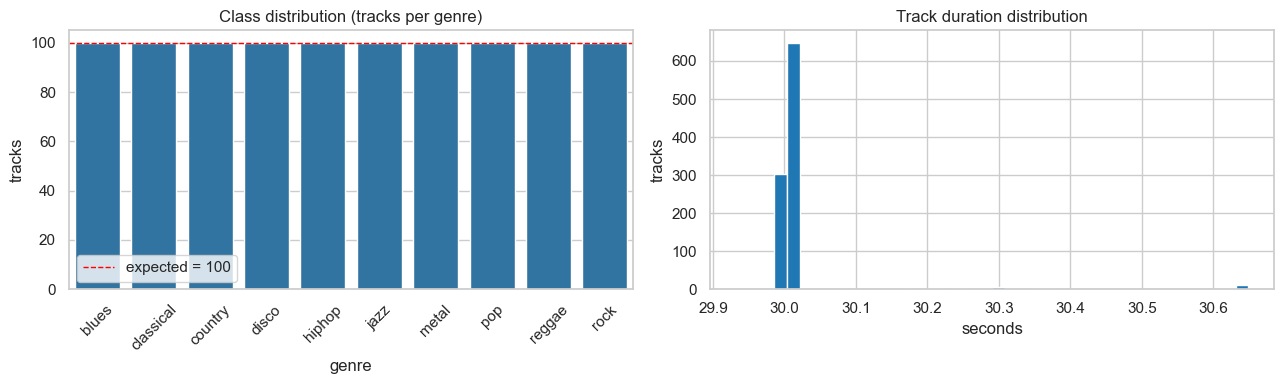

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = tracks.groupby('genre').size().sort_index()
sns.barplot(x=counts.index, y=counts.values, ax=axes[0], color='tab:blue')
axes[0].set_title('Class distribution (tracks per genre)')
axes[0].set_ylabel('tracks'); axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(100, color='red', ls='--', lw=1, label='expected = 100')
axes[0].legend()

axes[1].hist(ok.duration, bins=40, color='tab:blue')
axes[1].set_title('Track duration distribution')
axes[1].set_xlabel('seconds'); axes[1].set_ylabel('tracks')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_class_distribution_duration.png', dpi=150,
            bbox_inches='tight')
plt.show()

**Findings so far.** The 10 classes are perfectly balanced on disk, everything is
mono 22,050 Hz 16-bit, and durations sit tightly around 30 s. The integrity scan
surfaces the issues the literature warns about: any undecodable file(s) reported
above (GTZAN's `jazz.00054` is famously broken in several distributions), plus the
exact-repetition groups - consistent with Sturm (2013), who catalogued repetitions,
mislabellings and distortions in GTZAN. These faults are *handled explicitly* in
Section 5 (corrupted files excluded; duplicates pinned to the training set so they
can never straddle a split boundary).

## 2. Waveforms & Mel spectrograms

One representative track per genre. The waveform shows loudness/rhythm envelopes;
the Mel spectrogram shows how energy is distributed over frequency and time —
this is exactly the representation our CNN will consume.

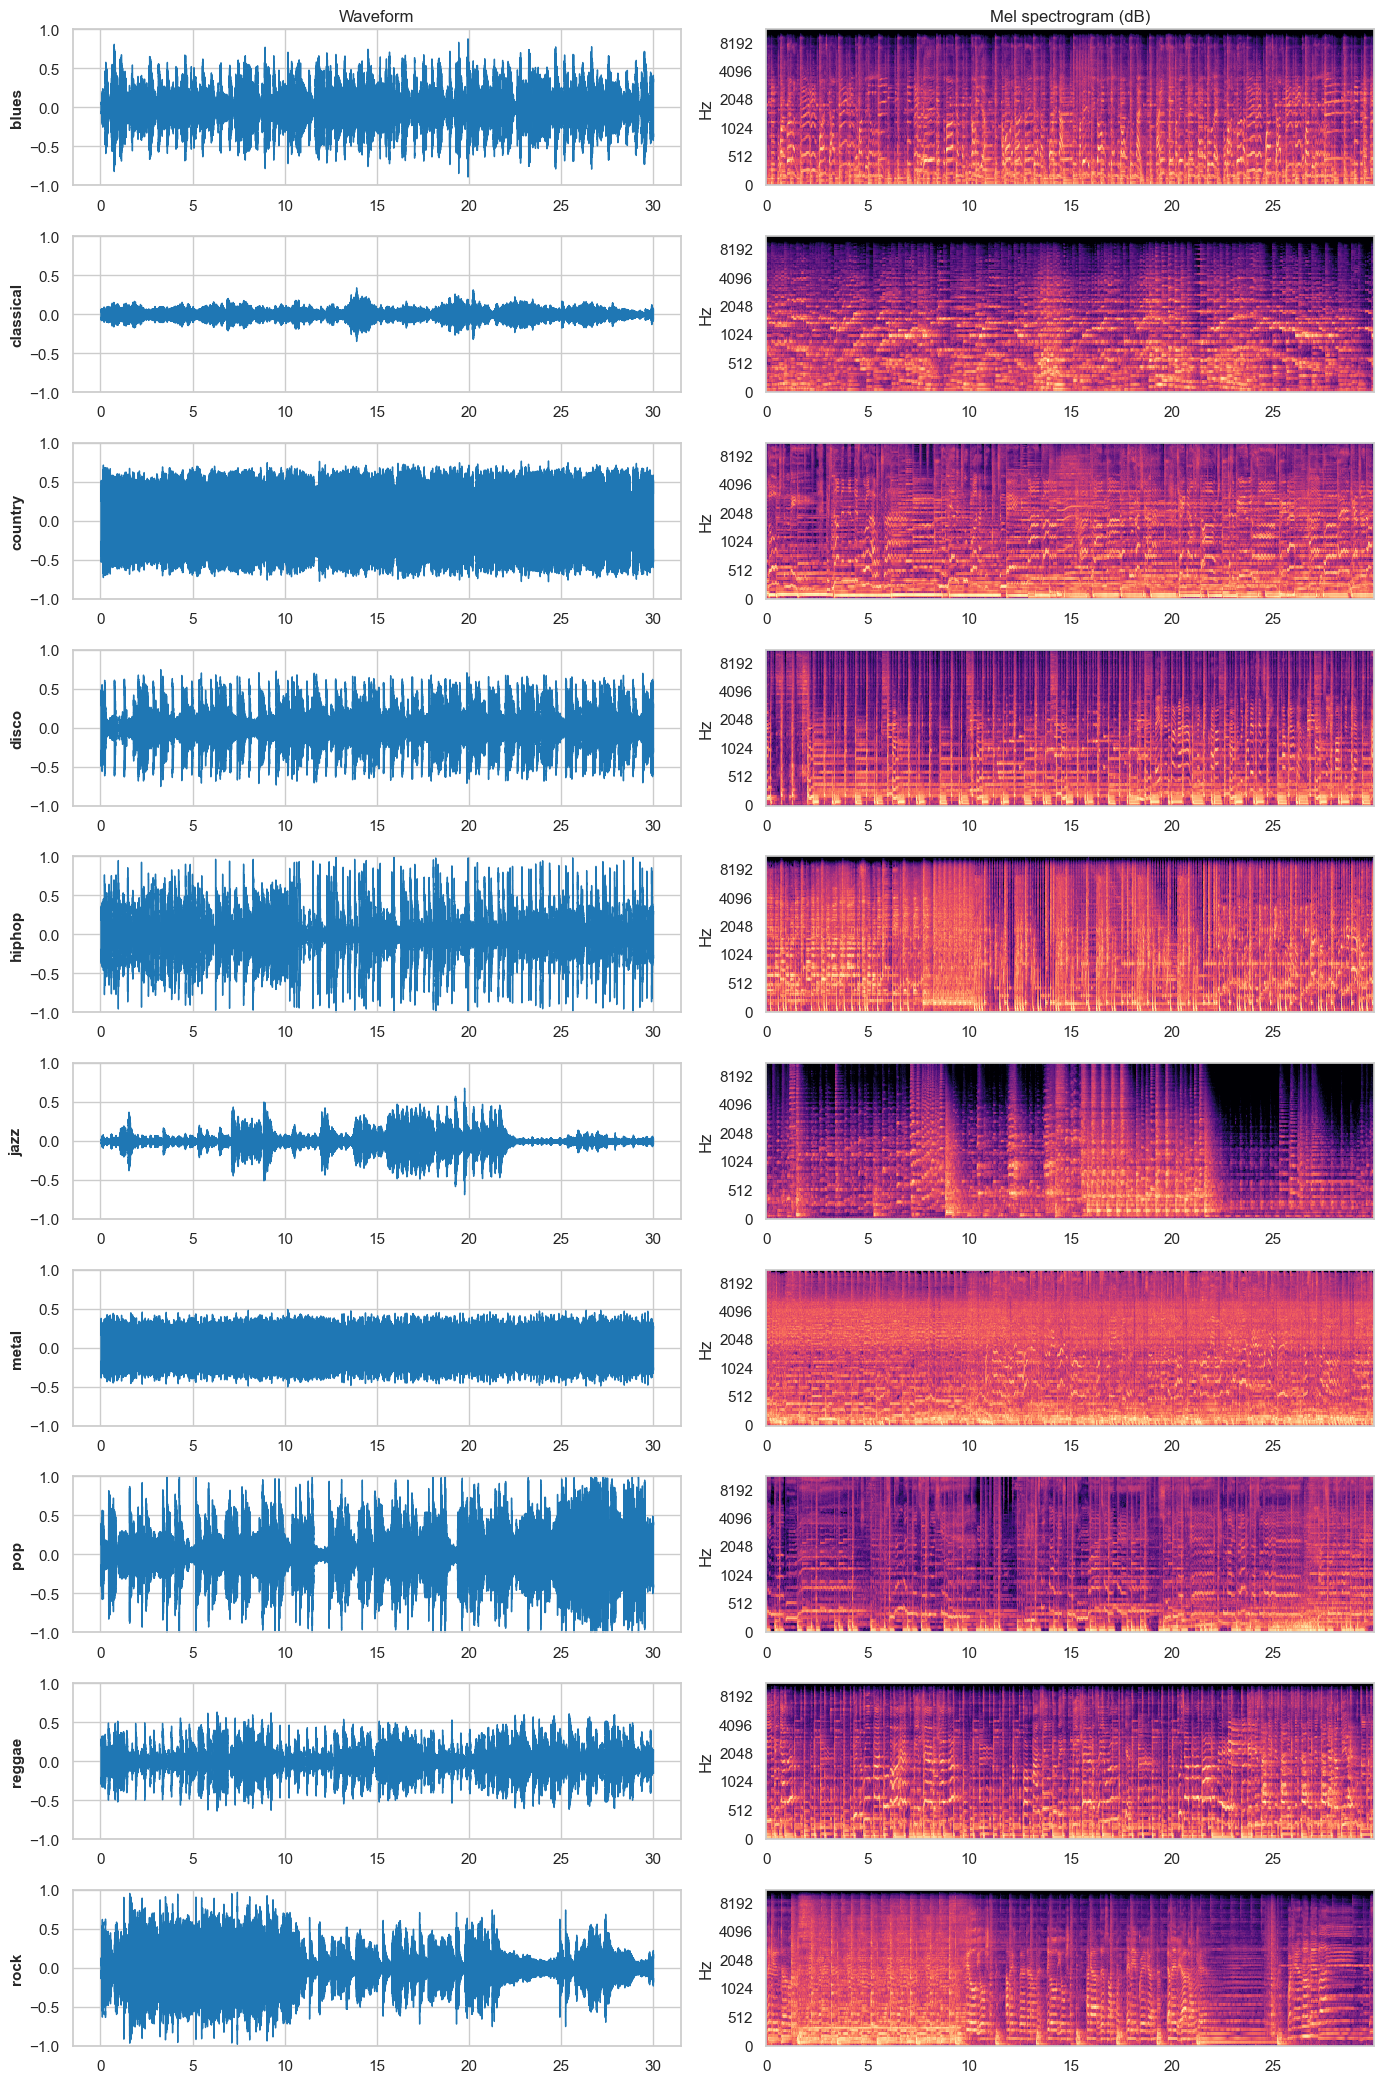

In [9]:
genres = sorted(tracks.genre.unique())
fig, axes = plt.subplots(len(genres), 2, figsize=(14, 2.1 * len(genres)))
for i, g in enumerate(genres):
    path = meta[(meta.genre == g) & meta.decode_ok].path.iloc[0]
    y, _ = librosa.load(path, sr=SR, duration=30)
    librosa.display.waveshow(y, sr=SR, ax=axes[i, 0], color='tab:blue')
    axes[i, 0].set_ylabel(g, fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(''); axes[i, 0].set_ylim(-1, 1)
    S = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128), ref=np.max)
    librosa.display.specshow(S, sr=SR, x_axis='time', y_axis='mel',
                             ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_xlabel('')
axes[0, 0].set_title('Waveform'); axes[0, 1].set_title('Mel spectrogram (dB)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_waveform_melspec_per_genre.png', dpi=150,
            bbox_inches='tight')
plt.show()

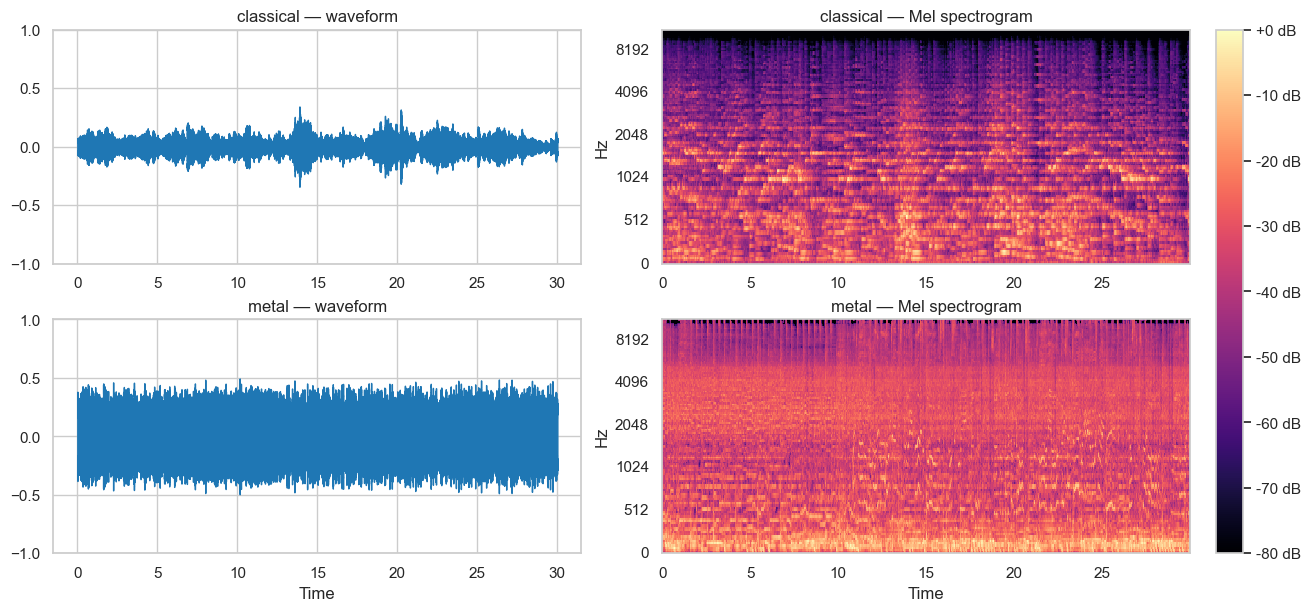

In [10]:
# Presentation-ready contrast: classical vs metal for example
fig, axes = plt.subplots(2, 2, figsize=(13, 6), layout='constrained')
for i, g in enumerate(['classical', 'metal']):
    path = meta[(meta.genre == g) & meta.decode_ok].path.iloc[0]
    y, _ = librosa.load(path, sr=SR, duration=30)
    librosa.display.waveshow(y, sr=SR, ax=axes[i, 0], color='tab:blue')
    axes[i, 0].set_title(f'{g} — waveform'); axes[i, 0].set_ylim(-1, 1)
    if i == 0:
        axes[i, 0].set_xlabel('')
    S = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128), ref=np.max)
    img = librosa.display.specshow(S, sr=SR, x_axis='time', y_axis='mel',
                                   ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_title(f'{g} — Mel spectrogram')
    if i == 0:
        axes[i, 1].set_xlabel('')
fig.colorbar(img, ax=axes[:, 1], format='%+2.0f dB')
plt.savefig(f'{FIG_DIR}/03_classical_vs_metal.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation.** The contrast is stark: classical music is quiet and dynamically
varied with energy concentrated in the low/mid Mel bands, while metal is a wall of
near-constant broadband energy reaching the top of the spectrum. Percussive genres
(hiphop, disco) show regular vertical striping (beats). This visual separability is
what motivates both the spectral features below and the Mel-spectrogram CNN.

## 3. Feature extraction → `features.csv`

For every decodable track we extract the slide-7 feature set with `librosa`,
summarising each frame-level feature by its mean and standard deviation over the
full 30 s:

| Feature | Columns | Captures |
|---|---|---|
| MFCC (20 coefficients) | `mfcc01..20_{mean,std}` | timbre / spectral envelope |
| Chroma (12 pitch classes) | `chroma01..12_{mean,std}` | harmony / key content |
| Zero-crossing rate | `zcr_{mean,std}` | noisiness / percussiveness |
| RMS energy | `rms_{mean,std}` | loudness |
| Spectral centroid / bandwidth / roll-off | `spectral_*_{mean,std}` | brightness, spread |
| Tempo (BPM) | `tempo` | rhythm |

Teammates building the KNN / SVM / Naïve Bayes baselines can consume
`features.csv` directly without touching the raw audio.

In [11]:
N_MFCC = 20
N_CHROMA = 12

def extract_features(path):
    y, sr = librosa.load(path, sr=SR, mono=True)
    feats = {'filename': os.path.basename(path)}
    feats['tempo'] = float(librosa.feature.tempo(y=y, sr=sr)[0])
    scalars = {
        'zcr': librosa.feature.zero_crossing_rate(y)[0],
        'rms': librosa.feature.rms(y=y)[0],
        'spectral_centroid': librosa.feature.spectral_centroid(y=y, sr=sr)[0],
        'spectral_bandwidth': librosa.feature.spectral_bandwidth(y=y, sr=sr)[0],
        'spectral_rolloff': librosa.feature.spectral_rolloff(y=y, sr=sr,
                                                             roll_percent=0.85)[0],
    }
    for name, arr in scalars.items():
        feats[f'{name}_mean'] = float(arr.mean())
        feats[f'{name}_std'] = float(arr.std())
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    for i in range(N_MFCC):
        feats[f'mfcc{i+1:02d}_mean'] = float(mfcc[i].mean())
        feats[f'mfcc{i+1:02d}_std'] = float(mfcc[i].std())
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=N_CHROMA)
    for i in range(N_CHROMA):
        feats[f'chroma{i+1:02d}_mean'] = float(chroma[i].mean())
        feats[f'chroma{i+1:02d}_std'] = float(chroma[i].std())
    return feats

valid = meta[meta.decode_ok]
rows = Parallel(n_jobs=-1, prefer='threads', verbose=1)(
    delayed(extract_features)(p) for p in valid.path)
features = valid[['filename', 'genre']].merge(pd.DataFrame(rows), on='filename')
features.to_csv('features.csv', index=False)

print(f'features.csv written: {features.shape[0]} tracks x '
      f'{features.shape[1] - 2} features')
assert not features.isna().any().any(), 'NaNs in extracted features!'
features.head() 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   45.9s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:  1.5min


features.csv written: 999 tracks x 75 features


[Parallel(n_jobs=-1)]: Done 999 out of 999 | elapsed:  2.0min finished


,filename,genre,tempo,zcr_mean,zcr_std,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,...,chroma08_mean,chroma08_std,chroma09_mean,chroma09_std,chroma10_mean,chroma10_std,chroma11_mean,chroma11_std,chroma12_mean,chroma12_std
0,blues.00000.wav,blues,123.046875,0.083045,0.027694,0.130184,0.053183,1784.122641,360.202005,2002.412407,...,0.435684,0.346125,0.295986,0.253740,0.315081,0.280609,0.407008,0.332963,0.385101,0.292690
1,blues.00001.wav,blues,107.666016,0.056040,0.038046,0.095908,0.048711,1530.261767,613.119490,2038.987608,...,0.560355,0.366813,0.384179,0.295294,0.255326,0.233186,0.284776,0.279027,0.334094,0.269174
2,blues.00002.wav,blues,161.499023,0.076291,0.031731,0.175473,0.052449,1552.832481,395.564168,1747.754087,...,0.288404,0.251398,0.334152,0.247275,0.401819,0.333114,0.384390,0.251500,0.588508,0.353000
3,blues.00003.wav,blues,172.265625,0.033309,0.020561,0.141040,0.079672,1070.153418,429.378632,1596.422564,...,0.251613,0.199384,0.246271,0.215075,0.315111,0.293744,0.316579,0.280990,0.383199,0.337257
4,blues.00004.wav,blues,135.999178,0.101461,0.044205,0.091501,0.048013,1835.128513,585.874983,1748.410758,...,0.139121,0.177100,0.276424,0.303410,0.324327,0.233583,0.555124,0.355836,0.272931,0.218418


## 4. Feature analysis

### 4.1 Which features discriminate between genres?

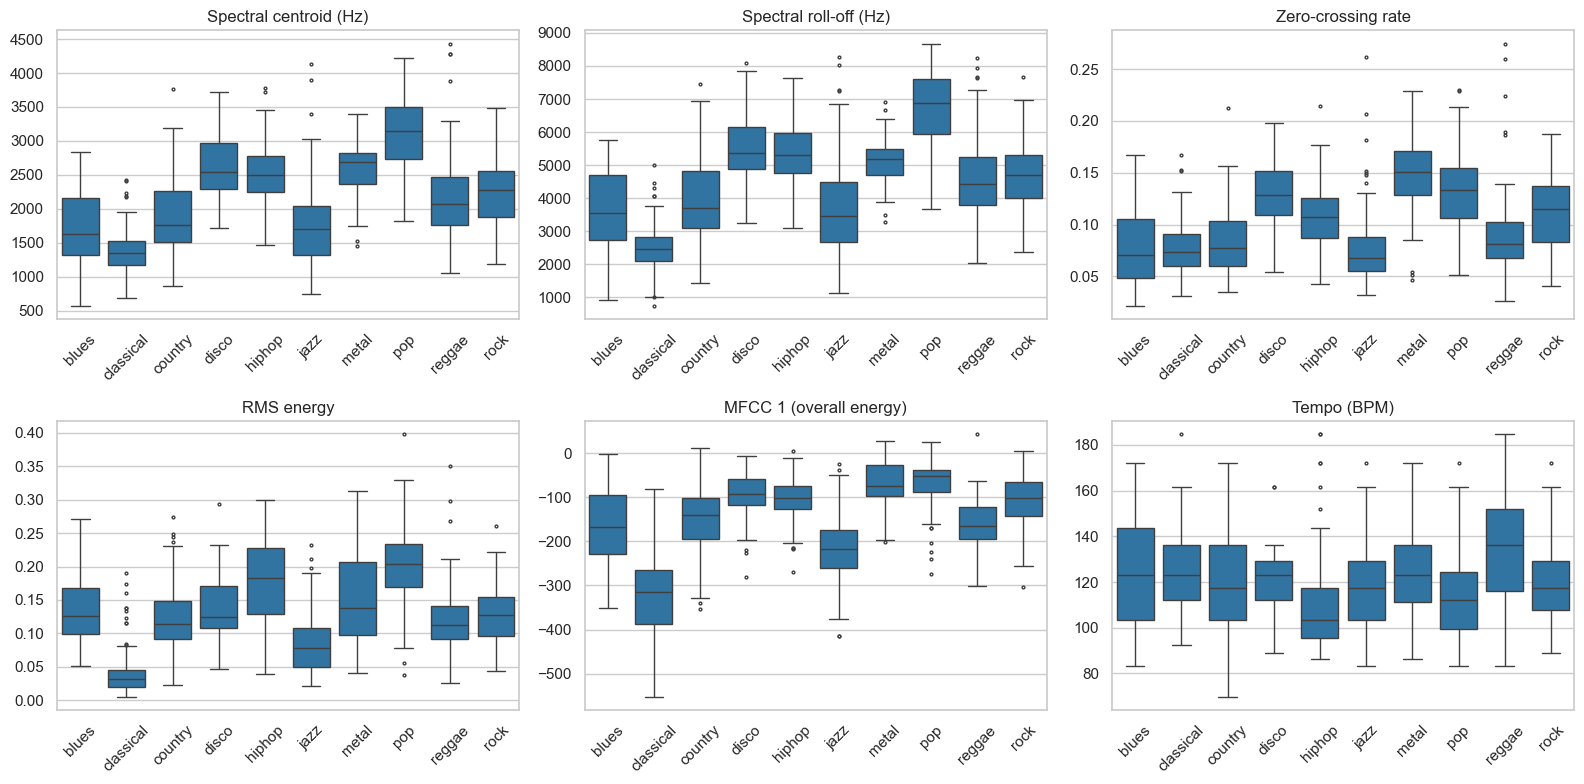

In [12]:
show = ['spectral_centroid_mean', 'spectral_rolloff_mean', 'zcr_mean',
        'rms_mean', 'mfcc01_mean', 'tempo']
titles = ['Spectral centroid (Hz)', 'Spectral roll-off (Hz)',
          'Zero-crossing rate', 'RMS energy', 'MFCC 1 (overall energy)',
          'Tempo (BPM)']
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
order = sorted(features.genre.unique())
for ax, col, title in zip(axes.ravel(), show, titles):
    sns.boxplot(data=features, x='genre', y=col, ax=ax, order=order,
                color='tab:blue', fliersize=2)
    ax.set_title(title); ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the box plots.** Spectral centroid / roll-off and zero-crossing rate
separate the "bright & noisy" genres (metal, pop, disco, hiphop) from classical
and jazz very cleanly; RMS energy singles out classical (quiet, wide dynamic
range) and metal (loud, compressed). Tempo alone is a weak discriminator - most
genres overlap heavily - which matches the intuition that timbre, not speed,
defines these genres.

For statistical analysis of which features discriminate the best, the respective F-scores and p-values were calsulated for each feature

In [35]:
from sklearn.feature_selection import f_classif, mutual_info_classif

feature_cols = [c for c in features.columns if c != 'genre' and c != 'filename']
X = features[feature_cols]
y = features['genre']

F_values, p_values = f_classif(X, y)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'F_stat': F_values,
    'p_value': p_values
}).sort_values('F_stat', ascending=False).reset_index(drop=True)

feature_importance[:15]

,feature,F_stat,p_value
0,mfcc01_mean,130.781715,1.214223e-161
1,spectral_bandwidth_mean,116.493135,1.400051e-148
2,spectral_centroid_std,113.348178,1.349861e-145
3,spectral_rolloff_mean,110.681722,4.932518e-143
4,spectral_centroid_mean,97.293036,1.099029e-129
5,rms_std,90.242868,2.598938e-122
6,zcr_std,85.267926,5.930591e-117
7,mfcc04_mean,83.940563,1.680203e-115
8,mfcc02_mean,83.028298,1.694813e-114
9,rms_mean,74.485772,7.245327e-105


From the above results, it can be seen that the most important feature for classification is the first mel frequency cepstral coefficient. However, it should also be noted that all of the features have really low p-values meaning that they are all relatively statistically significant.

Another experiment can be done to identify the features that result in the highest information gain for classification.

In [73]:
info_gain = mutual_info_classif(X, y, random_state=SEED)

information_gain_table = pd.DataFrame({
    'feature': feature_cols,
    'info_gain': info_gain
}).sort_values('info_gain', ascending=False).reset_index(drop=True)

information_gain_table.head(15)

,feature,info_gain
0,spectral_rolloff_mean,0.444622
1,spectral_bandwidth_mean,0.422881
2,spectral_centroid_mean,0.420038
3,spectral_centroid_std,0.410113
4,mfcc01_mean,0.383964
5,rms_mean,0.381125
6,rms_std,0.377312
7,zcr_std,0.341428
8,mfcc02_mean,0.321942
9,mfcc04_mean,0.320175


From the above results, including the spectral rolloff mean in the model results in an information gain of 0.4, making it highly necessary for classification.

### 4.2 Feature correlations 
#### Important for models that assume independence of features

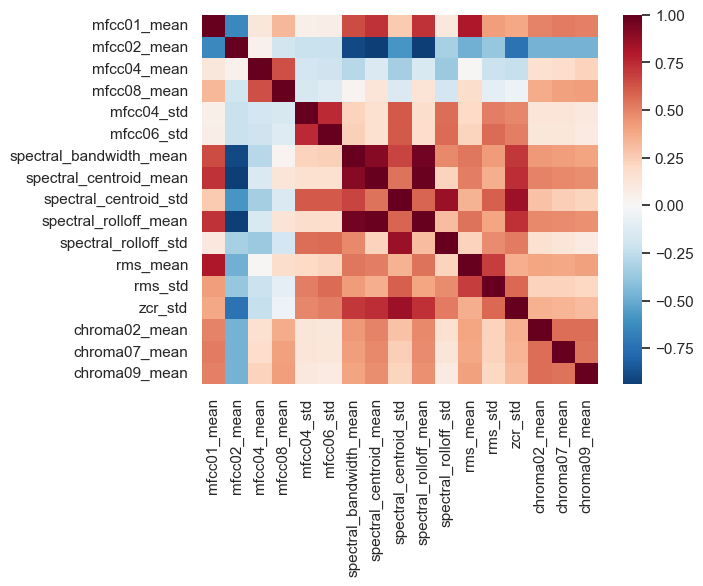

In [60]:
import seaborn as sns

best_features = [
    'mfcc01_mean',
    'mfcc02_mean',
    'mfcc04_mean',
    'mfcc08_mean',
    'mfcc04_std',
    'mfcc06_std',
    'spectral_bandwidth_mean',
    'spectral_centroid_mean',
    'spectral_centroid_std',
    'spectral_rolloff_mean',
    'spectral_rolloff_std',
    'rms_mean',
    'rms_std',
    'zcr_std',
    'chroma02_mean',
    'chroma07_mean',
    'chroma09_mean',
]

corr_matrix = X[best_features].corr()
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0)
plt.show()

In [72]:
corr_pairs = corr_matrix.stack().reset_index()

corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']

# Remove self-correlations and duplicates
corr_pairs = corr_pairs[corr_pairs['feature_1'] != corr_pairs['feature_2']]

corr_pairs['sorted_vars'] = corr_pairs.apply(  
    lambda row: tuple(sorted([row['feature_1'], row['feature_2']])), axis=1  
)  
 
corr_pairs = corr_pairs.drop_duplicates(subset='sorted_vars')
corr_pairs = corr_pairs.drop(columns='sorted_vars') 

# Select the top correlated
corr_pairs = corr_pairs[corr_pairs['correlation'] > 0.8]
top_corr = corr_pairs.sort_values(by='correlation', ascending=False).reset_index(drop=True)  
 
top_corr 

,feature_1,feature_2,correlation
0,spectral_centroid_mean,spectral_rolloff_mean,0.979621
1,spectral_bandwidth_mean,spectral_rolloff_mean,0.956278
2,spectral_bandwidth_mean,spectral_centroid_mean,0.904512
3,spectral_centroid_std,spectral_rolloff_std,0.859184
4,spectral_centroid_std,zcr_std,0.848817
5,mfcc01_mean,rms_mean,0.807248


From above, the spectral features are highly correlated

## 5 Genre Analysis

### 5.1 PCA - how separable are the genres?

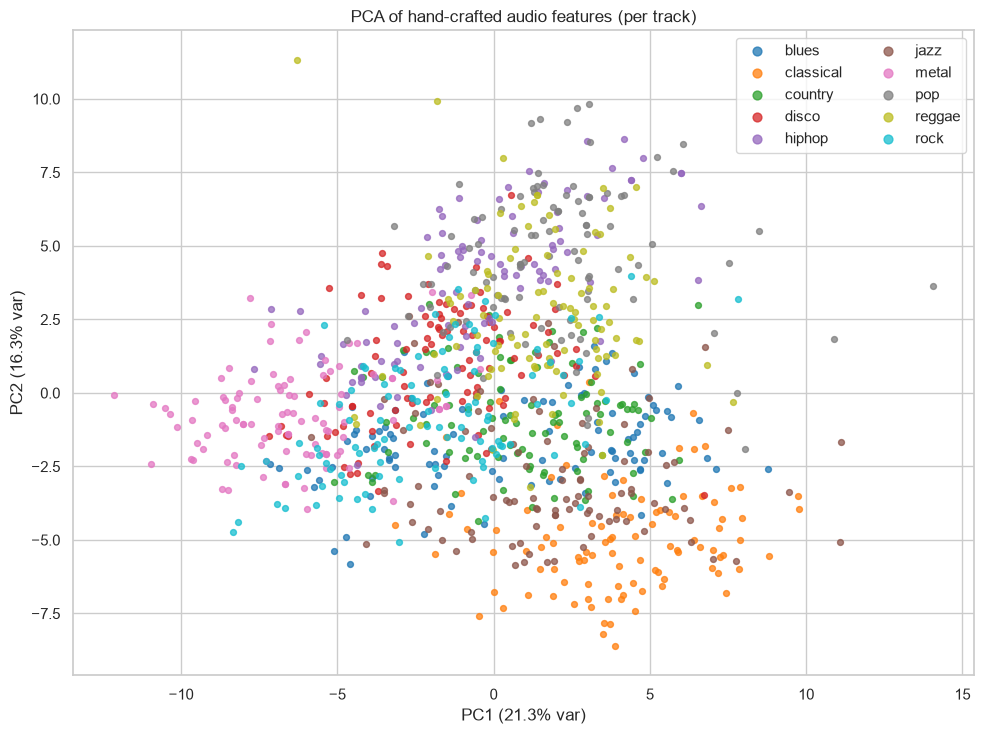

Total variance explained by 2 components: 37.5%


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(features.drop(columns=['filename', 'genre']))
pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(X)

plt.figure(figsize=(10, 7.5))
palette = sns.color_palette('tab10', len(order))
for g, c in zip(order, palette):
    m = (features.genre == g).values
    plt.scatter(Z[m, 0], Z[m, 1], s=18, alpha=0.75, color=c, label=g)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('PCA of hand-crafted audio features (per track)')
plt.legend(ncol=2, markerscale=1.5)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total variance explained by 2 components: '
      f'{pca.explained_variance_ratio_.sum():.1%}')

**Reading the PCA.** Classical forms its own tight cluster and metal sits at the
opposite extreme, while rock / country / blues (and disco / pop / hiphop) blur into
each other in the middle. We therefore expect the confusion matrix in the Results
section to be nearly diagonal for classical and metal, with most errors among the
rock/country/blues neighbourhood - a prediction we will check against the trained
models.


### 5.2 LDA Analysis - Class separation

LDA, unlike PCA maximises class separation by actively using the target variable 
("genre") to rotate the data. It finds the specific combinations of features that 
are best at discriminating between classes. These are the components that maximise 
the distance between genres creating a cleaner, more interpretable visual of the 
separability of the genres.


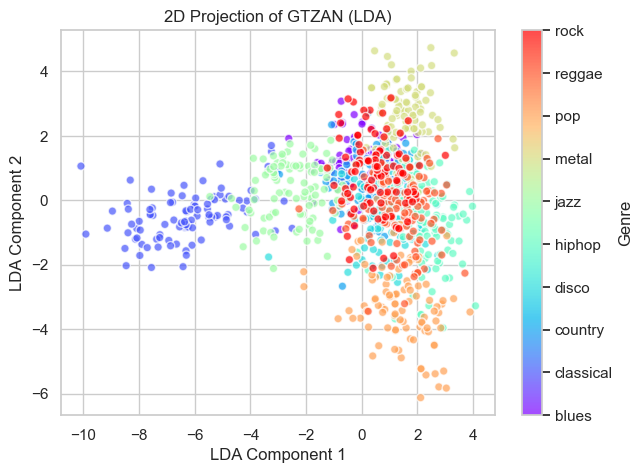

In [77]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

y_encoded, genre_names = pd.factorize(y)

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111)

scatter = ax.scatter(
    X_lda[:, 0],  # LDA Component 1
    X_lda[:, 1],  # LDA Component 2
    c=y_encoded,  # Color by your target/genre
    cmap="rainbow",
    alpha=0.7,
    edgecolors="w",
)

ax.set_xlabel("LDA Component 1")
ax.set_ylabel("LDA Component 2")
ax.set_title("2D Projection of GTZAN (LDA)")

# 5. Add a colorbar legend
cbar = plt.colorbar(scatter, label="Genre")
cbar.set_ticks(range(len(genre_names)))
cbar.set_ticklabels(genre_names)
plt.show()

The LDA analysis above, further confirms how well classical music is separated from the rest. This plot gives a bit more insight into the separatability of more genres too. Jazz is relatively separated from the other clusters, and so is metal and pop. The rest of the genres are still really closely clustered showing that there isn't enough unique information for them to be easily separated.

## 5. Train / validation / test split → `split.csv`

TO DO